✅ STEP 0: Libraries imported.

=== STEP 1: LOAD DATA ===
Loaded: C:/Users/mr.venky/Downloads/breast-cancer.csv
Shape: (569, 32)
Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38           122.8     1001.0   
1    842517         M        20.57         17.77           132.9     1326.0   
2  84300903         M        19.69         21.25           13

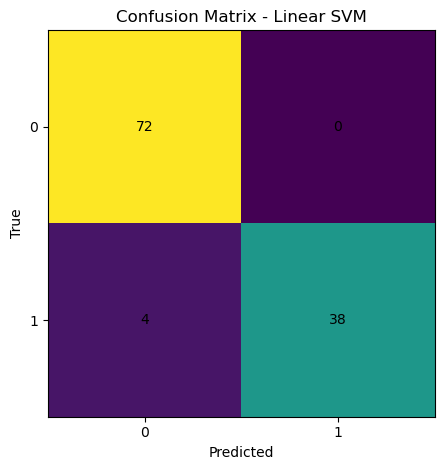

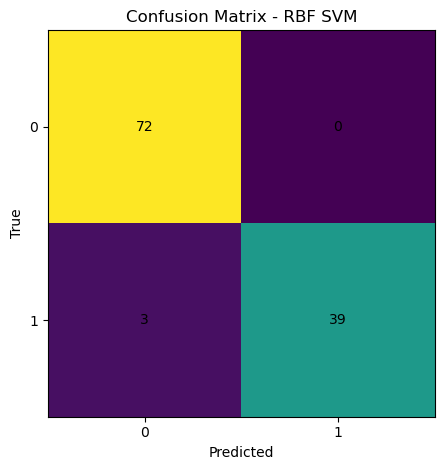


=== STEP 6: HYPERPARAMETER TUNING (GridSearchCV) ===
Best Params: {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best CV Accuracy: 0.9789
Cross-val scores: [0.9737 0.9737 0.9825 0.9737 0.9912]
Mean CV accuracy: 0.9789

=== STEP 7: DECISION BOUNDARY (2D PCA) ===


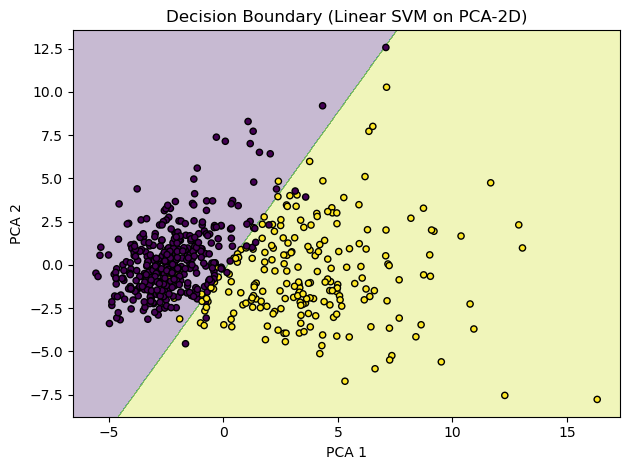

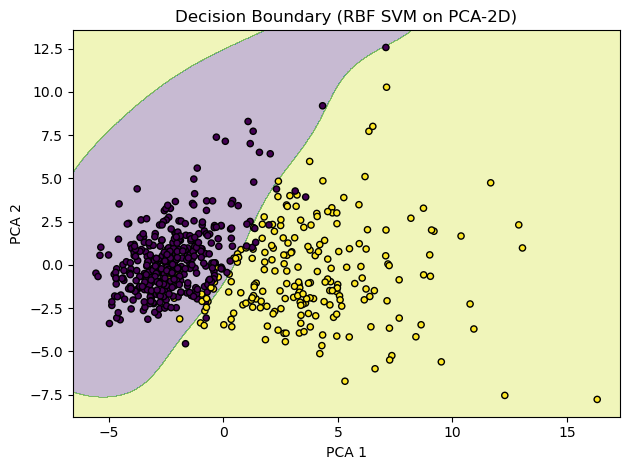


✅ DONE. You now have:
1) Clean loading and label encoding
2) Baseline Linear & RBF SVM with scaling
3) Confusion matrices & classification reports
4) GridSearchCV tuning for C & gamma (linear/RBF)
5) Cross-validation accuracy
6) 2D PCA decision boundary plots (for visualization only)


In [1]:
# STEP 0: Imports & utility setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ STEP 0: Libraries imported.")


# STEP 1: Load the dataset
print("\n=== STEP 1: LOAD DATA ===")
path = "C:/Users/mr.venky/Downloads/breast-cancer.csv"
df = pd.read_csv(path)
print("Loaded:", path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head(3))


# STEP 2: Basic cleaning & target/feature split
print("\n=== STEP 2: PREPARE FEATURES & TARGET ===")
# Drop an ID column if present
df = df.drop(columns=["id"], errors="ignore")

# Separate features (X) and target (y)
if "diagnosis" not in df.columns:
    raise ValueError("Expected a 'diagnosis' column as target but did not find it.")

X = df.drop(columns=["diagnosis"])
y_raw = df["diagnosis"]

# Encode labels (B/M) to 0/1
le = LabelEncoder()
y = le.fit_transform(y_raw)  # Benign (B)=0, Malignant (M)=1, in alphabetical order
print("Label classes (in order):", list(le.classes_))


# STEP 3: Train-test split
print("\n=== STEP 3: TRAIN/TEST SPLIT ===")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


# STEP 4: Build pipelines for Linear and RBF SVMs (with scaling)
print("\n=== STEP 4: TRAIN BASELINE SVM MODELS ===")
pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", probability=False))
])

pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", gamma="scale", probability=False))
])

# Fit and evaluate Linear SVM
pipe_linear.fit(X_train, y_train)
y_pred_lin = pipe_linear.predict(X_test)
acc_lin = accuracy_score(y_test, y_pred_lin)
print("Linear SVM Accuracy (test):", round(acc_lin, 4))

# Fit and evaluate RBF SVM
pipe_rbf.fit(X_train, y_train)
y_pred_rbf = pipe_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print("RBF SVM Accuracy (test):", round(acc_rbf, 4))


# STEP 5: Classification reports & Confusion Matrices
print("\n=== STEP 5: EVALUATION REPORTS ===")
target_names = [f"{cls} ({i})" for i, cls in enumerate(le.classes_)]
print("\nLinear SVM Classification Report:\n", classification_report(y_test, y_pred_lin, target_names=target_names))
print("\nRBF SVM Classification Report:\n", classification_report(y_test, y_pred_rbf, target_names=target_names))

# Confusion matrix plots (Linear)
cm_lin = confusion_matrix(y_test, y_pred_lin, labels=[0, 1])
plt.figure()
plt.imshow(cm_lin, interpolation='nearest')
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1],[0,1])
plt.yticks([0,1],[0,1])
for i in range(cm_lin.shape[0]):
    for j in range(cm_lin.shape[1]):
        plt.text(j, i, cm_lin[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

# Confusion matrix plots (RBF)
cm_rbf = confusion_matrix(y_test, y_pred_rbf, labels=[0, 1])
plt.figure()
plt.imshow(cm_rbf, interpolation='nearest')
plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1],[0,1])
plt.yticks([0,1],[0,1])
for i in range(cm_rbf.shape[0]):
    for j in range(cm_rbf.shape[1]):
        plt.text(j, i, cm_rbf[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


# STEP 6: Hyperparameter tuning with cross-validation
print("\n=== STEP 6: HYPERPARAMETER TUNING (GridSearchCV) ===")
param_grid = [
    {  # Linear kernel: tune C only
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {  # RBF kernel: tune C and gamma
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": [0.001, 0.01, 0.1, 1],
    },
]

pipe = Pipeline([("scaler", StandardScaler()), ("svc", SVC())])
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=None,
)
grid.fit(X, y)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_, 4))

# Evaluate best model with 5-fold CV explicitly
best_model = grid.best_estimator_
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="accuracy")
print("Cross-val scores:", np.round(cv_scores, 4))
print("Mean CV accuracy:", round(cv_scores.mean(), 4))


# STEP 7: Visualize decision boundary using 2D PCA projection
print("\n=== STEP 7: DECISION BOUNDARY (2D PCA) ===")
# Standardize entire X for visualization purposes
scaler_vis = StandardScaler().fit(X)
X_scaled = scaler_vis.transform(X)

# PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Train linear & rbf SVMs on 2D PCA data (for plotting only)
svm_lin_2d = SVC(kernel="linear", C=1)
svm_lin_2d.fit(X_pca, y)

svm_rbf_2d = SVC(kernel="rbf", C=1, gamma="scale")
svm_rbf_2d.fit(X_pca, y)

def plot_decision_boundary_2d(model, X2d, y1d, title):
    # Create grid
    h = 0.02
    x_min, x_max = X2d[:, 0].min() - 1, X2d[:, 0].max() + 1
    y_min, y_max = X2d[:, 1].min() - 1, X2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    # Plot
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    # Use class-coded colors implicitly (no explicit colors set)
    plt.scatter(X2d[:, 0], X2d[:, 1], c=y1d, edgecolors='k', s=20)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.tight_layout()
    plt.show()

plot_decision_boundary_2d(svm_lin_2d, X_pca, y, "Decision Boundary (Linear SVM on PCA-2D)")
plot_decision_boundary_2d(svm_rbf_2d, X_pca, y, "Decision Boundary (RBF SVM on PCA-2D)")

print("\n✅ DONE. You now have:")
print("1) Clean loading and label encoding")
print("2) Baseline Linear & RBF SVM with scaling")
print("3) Confusion matrices & classification reports")
print("4) GridSearchCV tuning for C & gamma (linear/RBF)")
print("5) Cross-validation accuracy")
print("6) 2D PCA decision boundary plots (for visualization only)")
